# AutoFitter Tutorial

This notebook demonstrates how to use the `AutoFitter` class for automatic distribution selection and comparison.

## Overview

`AutoFitter` is designed to:
- Automatically test multiple probability distributions
- Select the best-fitting distribution based on various criteria (RMSE, AIC, BIC, etc.)
- Support all 113 SciPy continuous distributions
- Use lazy initialization for memory efficiency
- Provide comprehensive comparison tables and rankings

## Setup and Data Generation

Let's create some sample data that follows a known distribution to test AutoFitter's capability.

Generated 1000 wind speed measurements
Min: 0.69 m/s
Max: 27.57 m/s
Mean: 7.04 m/s
Std: 3.70 m/s


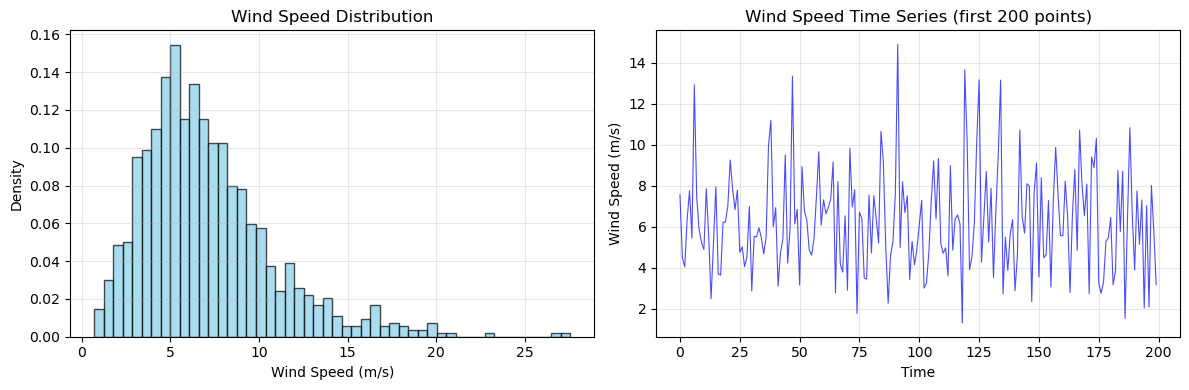

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import magica as ma
from magica.core.auto_fitter import AutoFitter

# Set random seed for reproducibility
np.random.seed(123)

# Generate mixed wind speed data (complex scenario)
# Simulate different weather conditions
low_wind = np.random.weibull(2, 400) * 6 + 1    # Calm periods
normal_wind = np.random.lognormal(2, 0.5, 400)  # Variable periods  
high_wind = np.random.gamma(3, 2, 200)          # Storm periods

# Combine all periods
wind_data = np.concatenate([low_wind, normal_wind, high_wind])

print(f"Generated {len(wind_data)} wind speed measurements")
print(f"Min: {wind_data.min():.2f} m/s")
print(f"Max: {wind_data.max():.2f} m/s")
print(f"Mean: {wind_data.mean():.2f} m/s")
print(f"Std: {wind_data.std():.2f} m/s")

# Visualize the data
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(wind_data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Density')
plt.title('Wind Speed Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(wind_data[:200], 'b-', alpha=0.7, linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.title('Wind Speed Time Series (first 200 points)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Basic AutoFitter Usage

Let's start with the default configuration that tests a curated set of stable distributions.

In [2]:
# Load data into MagicA
processor = ma.read_data(wind_data)
print(f"Loaded data: {processor}")

# Create AutoFitter with default settings
auto_fitter = processor.get_auto_fitter(criterion='rmse')
print(f"\nCreated AutoFitter: {auto_fitter}")
print(f"Default candidates ({len(auto_fitter.candidates)}): {auto_fitter.candidates}")

Loaded data: DataProcessor(length=1000, dtype=float64)

Created AutoFitter: AutoFitter(candidates=16, criterion=rmse, not fitted)
Default candidates (16): ['weibull_min', 'lognorm', 'gamma', 'norm', 'expon', 'rayleigh', 'chi2', 'beta', 'uniform', 'logistic', 'gumbel_r', 'pareto', 'invgamma', 'maxwell', 'triang', 'laplace']


In [3]:
# Find the best distribution automatically
print("Finding best distribution from default candidates...")
best_result = auto_fitter.fit_best_distribution()

print(f"\n🏆 Best Distribution: {best_result['distribution']}")
print(f"📊 RMSE: {best_result['rmse']:.6f}")
print(f"📈 AIC: {best_result['aic']:.2f}")
print(f"📉 BIC: {best_result['bic']:.2f}")
print(f"🔍 KS p-value: {best_result['ks_pvalue']:.6f}")
print(f"⚙️ Parameters: {best_result['parameters']}")

Finding best distribution from default candidates...
Testing 16 distributions...
  [1/16] Fitting weibull_min...
  [2/16] Fitting lognorm...
  [3/16] Fitting gamma...
  [4/16] Fitting norm...
  [5/16] Fitting expon...
  [6/16] Fitting rayleigh...
  [7/16] Fitting chi2...
  [8/16] Fitting beta...
  [9/16] Fitting uniform...
  [10/16] Fitting logistic...
  [11/16] Fitting gumbel_r...
  [12/16] Fitting pareto...
  [13/16] Fitting invgamma...
  [14/16] Fitting maxwell...
  [15/16] Fitting triang...
  [16/16] Fitting laplace...
✓ All distributions fitted successfully

🏆 Best Distribution: invgamma
📊 RMSE: 0.005408
📈 AIC: 5223.26
📉 BIC: 5237.99
🔍 KS p-value: 0.987903
⚙️ Parameters: (np.float64(11.904082560566334), np.float64(-4.656117427894967), np.float64(127.54022278354164))


/home/daniloceano/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/home/daniloceano/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


## Comprehensive Distribution Comparison

Let's look at how all tested distributions performed.

In [4]:
# Get comprehensive comparison table
comparison = auto_fitter.get_comparison_table(sort_by='rmse')

print("📊 Distribution Ranking (by RMSE):")
print("=" * 80)
print(f"{'Rank':<4} {'Distribution':<15} {'RMSE':<12} {'AIC':<10} {'KS p-value':<12} {'Status'}")
print("=" * 80)

successful_results = [(dist, result) for dist, result in comparison.items() if result['success']]
failed_results = [(dist, result) for dist, result in comparison.items() if not result['success']]

# Show top 10 successful fits
for i, (dist, result) in enumerate(successful_results[:10], 1):
    status = "✅ Good" if result['ks_pvalue'] > 0.05 else "⚠️ Fair"
    print(f"{i:<4} {dist:<15} {result['rmse']:<12.6f} {result['aic']:<10.1f} {result['ks_pvalue']:<12.6f} {status}")

print(f"\n📊 Summary:")
print(f"✅ Successful fits: {len(successful_results)}")
print(f"❌ Failed fits: {len(failed_results)}")
if failed_results:
    print(f"Failed distributions: {[dist for dist, _ in failed_results]}")

📊 Distribution Ranking (by RMSE):
Rank Distribution    RMSE         AIC        KS p-value   Status
1    invgamma        0.005408     5223.3     0.987903     ✅ Good
2    gumbel_r        0.005897     5224.6     0.980487     ✅ Good
3    lognorm         0.007012     5223.3     0.938914     ✅ Good
4    gamma           0.012079     5227.6     0.672461     ✅ Good
5    beta            0.022798     5263.6     0.042823     ⚠️ Fair
6    weibull_min     0.024757     5255.5     0.063202     ✅ Good
7    logistic        0.027776     5379.4     0.005291     ⚠️ Fair
8    rayleigh        0.031457     5267.5     0.002930     ⚠️ Fair
9    laplace         0.032053     5397.8     0.000141     ⚠️ Fair
10   maxwell         0.039045     5305.1     0.000121     ⚠️ Fair

📊 Summary:
✅ Successful fits: 16
❌ Failed fits: 0


## Using the Best-Fitted Distribution

Once we have the best distribution, we can use it just like a regular MagicAdjuster.

In [5]:
# Get the adjuster for the best distribution
best_adjuster = auto_fitter.get_best_adjuster()
print(f"Best adjuster: {best_adjuster}")

# Use it like any MagicAdjuster - calculate key statistics
mean_wind = best_adjuster.stats(moments='m')
percentile_50 = best_adjuster.ppf(0.5)   # Median
percentile_95 = best_adjuster.ppf(0.95)  # 95th percentile
percentile_99 = best_adjuster.ppf(0.99)  # 99th percentile

print(f"\n📊 Wind Speed Statistics (from best-fitted {best_result['distribution']}):")
print(f"Mean: {mean_wind:.2f} m/s")
print(f"Median (50th percentile): {percentile_50:.2f} m/s")
print(f"95th percentile: {percentile_95:.2f} m/s")
print(f"99th percentile: {percentile_99:.2f} m/s")

# Calculate probabilities for specific thresholds
prob_exceed_15 = 1 - best_adjuster.cdf(15)  # P(wind > 15 m/s)
prob_below_5 = best_adjuster.cdf(5)          # P(wind ≤ 5 m/s)

print(f"\n⚡ Risk Assessment:")
print(f"Probability of exceeding 15 m/s: {prob_exceed_15:.4f} ({prob_exceed_15*100:.2f}%)")
print(f"Probability of calm conditions (≤ 5 m/s): {prob_below_5:.4f} ({prob_below_5*100:.2f}%)")

Best adjuster: MagicAdjuster(data_size=1000, distribution='invgamma')

📊 Wind Speed Statistics (from best-fitted invgamma):
Mean: 7.04 m/s
Median (50th percentile): 6.36 m/s
95th percentile: 13.96 m/s
99th percentile: 19.12 m/s

⚡ Risk Assessment:
Probability of exceeding 15 m/s: 0.0359 (3.59%)
Probability of calm conditions (≤ 5 m/s): 0.3224 (32.24%)


## Testing All Available Distributions

For the most comprehensive analysis, let's test ALL 113 available distributions!

In [6]:
# Get all available distributions
all_distributions = AutoFitter.get_all_available_distributions()
print(f"🌍 Total available distributions: {len(all_distributions)}")
print(f"First 20: {all_distributions[:20]}")
print(f"Last 20: {all_distributions[-20:]}")

# Create AutoFitter with ALL distributions
print("\n⚠️  Warning: Testing all distributions takes longer but is more comprehensive")
auto_fitter_comprehensive = processor.get_auto_fitter(
    candidates=all_distributions,  # Use ALL 113 distributions!
    criterion='aic'  # Let's use AIC this time
)

print(f"Created comprehensive AutoFitter: {auto_fitter_comprehensive}")

🌍 Total available distributions: 111
First 20: ['alpha', 'anglit', 'arcsine', 'argus', 'beta', 'betaprime', 'bradford', 'burr', 'burr12', 'cauchy', 'chi', 'chi2', 'cosine', 'crystalball', 'dgamma', 'dpareto_lognorm', 'dweibull', 'erlang', 'expon', 'exponnorm']
Last 20: ['skewcauchy', 'skewnorm', 'students_t', 't', 'trapezoid', 'trapz', 'triang', 'truncexpon', 'truncnorm', 'truncpareto', 'truncweibull_min', 'tukeylambda', 'uniform', 'vonmises', 'vonmises_line', 'wald', 'weibull', 'weibull_max', 'weibull_min', 'wrapcauchy']

⚠️  Warning: Testing all distributions takes longer but is more comprehensive
Created comprehensive AutoFitter: AutoFitter(candidates=111, criterion=aic, not fitted)


In [7]:
# Find best from ALL distributions (this takes a moment...)
print("🔍 Testing ALL 113 distributions... (this may take 30-60 seconds)")
best_comprehensive = auto_fitter_comprehensive.fit_best_distribution()

print(f"\n🏆 Best Distribution (from ALL 113): {best_comprehensive['distribution']}")
print(f"📊 AIC: {best_comprehensive['aic']:.2f}")
print(f"📈 RMSE: {best_comprehensive['rmse']:.6f}")
print(f"🔍 KS p-value: {best_comprehensive['ks_pvalue']:.6f}")

# Compare with default selection
print(f"\n🔬 Comparison:")
print(f"Default selection ({len(auto_fitter.candidates)} dists): {best_result['distribution']} (RMSE: {best_result['rmse']:.6f})")
print(f"Comprehensive ({len(all_distributions)} dists): {best_comprehensive['distribution']} (RMSE: {best_comprehensive['rmse']:.6f})")

improvement = ((best_result['rmse'] - best_comprehensive['rmse']) / best_result['rmse']) * 100
print(f"Improvement: {improvement:.2f}% reduction in RMSE")

🔍 Testing ALL 113 distributions... (this may take 30-60 seconds)
Testing 111 distributions...
  [1/111] Fitting alpha...
  [2/111] Fitting anglit...
  [3/111] Fitting arcsine...
  [4/111] Fitting argus...
  [5/111] Fitting beta...
  [6/111] Fitting betaprime...
  [7/111] Fitting bradford...
  [8/111] Fitting burr...
  [9/111] Fitting burr12...
  [10/111] Fitting cauchy...
  [11/111] Fitting chi...
  [12/111] Fitting chi2...
  [13/111] Fitting cosine...
  [14/111] Fitting crystalball...
  [15/111] Fitting dgamma...
  [16/111] Fitting dpareto_lognorm...


/home/daniloceano/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:1956: RuntimeWarning: divide by zero encountered in divide
  out = (a * b) / ((a - k) * (b + k)) * np.exp(k * m + k ** 2 * s ** 2 / 2)


  [17/111] Fitting dweibull...
  [18/111] Fitting erlang...
  [19/111] Fitting expon...
  [20/111] Fitting exponnorm...
  [21/111] Fitting exponpow...
  [22/111] Fitting exponweib...


/home/daniloceano/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value np.float64(2.1).
  fx = function(np.copy(x), *(wrapper_args + args))
/home/daniloceano/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value np.float64(2.0666666666666664).
  fx = function(np.copy(x), *(wrapper_args + args))
/home/daniloceano/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value np.float64(2.0999999999999996).
  fx = function(np.copy(x), *(wrapper_args + args))
/home/daniloceano/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape parameter of the erlang distrib

  [23/111] Fitting f...
  [24/111] Fitting fatiguelife...
  [25/111] Fitting fisk...
  [26/111] Fitting foldcauchy...
  [27/111] Fitting foldnorm...
  [28/111] Fitting gamma...
  [29/111] Fitting gausshyper...
  [30/111] Fitting genexpon...
  [31/111] Fitting genextreme...
  [32/111] Fitting gengamma...
  [33/111] Fitting genhalflogistic...
  [34/111] Fitting genhyperbolic...
  [35/111] Fitting geninvgauss...
  [36/111] Fitting genlogistic...
  [37/111] Fitting gennorm...
  [38/111] Fitting genpareto...
  [39/111] Fitting gibrat...
  [40/111] Fitting gompertz...
  [41/111] Fitting gumbel_l...
  [42/111] Fitting gumbel_r...
  [43/111] Fitting halfcauchy...
  [44/111] Fitting halfgennorm...
  [45/111] Fitting halflogistic...
  [46/111] Fitting halfnorm...
  [47/111] Fitting hypsecant...
  [48/111] Fitting invgamma...
  [49/111] Fitting invgauss...
  [50/111] Fitting invweibull...
  [51/111] Fitting irwinhall...
  [52/111] Fitting jf_skew_t...
  [53/111] Fitting johnsonsb...


/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/auto_fitter.py:208: UserWarning: Failed to fit irwinhall: Failed to fit irwinhall distribution: The generic `fit` implementation is unreliable for this distribution, and no custom implementation is available. Consider using `scipy.stats.fit`.
  warnings.warn(f"Failed to fit {distribution}: {e}")


  [54/111] Fitting johnsonsu...
  [55/111] Fitting kappa3...
  [56/111] Fitting kappa4...
  [57/111] Fitting ksone...
  [58/111] Fitting kstwo...
  [59/111] Fitting kstwobign...
  [60/111] Fitting landau...
  [61/111] Fitting laplace...
  [62/111] Fitting laplace_asymmetric...
  [63/111] Fitting levy...
  [64/111] Fitting levy_l...
  [65/111] Fitting loggamma...
  [66/111] Fitting logistic...
  [67/111] Fitting loglaplace...
  [68/111] Fitting lognorm...
  [69/111] Fitting loguniform...


/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/auto_fitter.py:208: UserWarning: Failed to fit kstwo: Failed to fit kstwo distribution: Iteration of zero-sized operands is not enabled
  warnings.warn(f"Failed to fit {distribution}: {e}")


  [70/111] Fitting lomax...
  [71/111] Fitting maxwell...
  [72/111] Fitting mielke...
  [73/111] Fitting moyal...
  [74/111] Fitting nakagami...
  [75/111] Fitting ncf...
  [76/111] Fitting nct...
  [77/111] Fitting ncx2...
  [78/111] Fitting norm...
  [79/111] Fitting norminvgauss...
  [80/111] Fitting pareto...
  [81/111] Fitting pearson3...
  [82/111] Fitting powerlaw...
  [83/111] Fitting powerlognorm...
  [84/111] Fitting powernorm...
  [85/111] Fitting rayleigh...
  [86/111] Fitting rdist...
  [87/111] Fitting recipinvgauss...
  [88/111] Fitting reciprocal...
  [89/111] Fitting rel_breitwigner...
  [90/111] Fitting rice...
  [91/111] Fitting semicircular...
  [92/111] Fitting skewcauchy...
  [93/111] Fitting skewnorm...
  [94/111] Fitting students_t...
  [95/111] Fitting t...
  [96/111] Fitting trapezoid...
  [97/111] Fitting trapz...
  [98/111] Fitting triang...
  [99/111] Fitting truncexpon...
  [100/111] Fitting truncnorm...
  [101/111] Fitting truncpareto...
  [102/111] Fitt

## Top Performers Analysis

Let's analyze the top-performing distributions from the comprehensive test.

In [8]:
# Get comprehensive comparison
comprehensive_comparison = auto_fitter_comprehensive.get_comparison_table(sort_by='aic')
successful_comprehensive = [(dist, result) for dist, result in comprehensive_comparison.items() if result['success']]
failed_comprehensive = [dist for dist, result in comprehensive_comparison.items() if not result['success']]

print(f"📊 Comprehensive Results Summary:")
print(f"✅ Successfully fitted: {len(successful_comprehensive)}/113 distributions")
print(f"❌ Failed to fit: {len(failed_comprehensive)} distributions")
print(f"Success rate: {len(successful_comprehensive)/113*100:.1f}%")

print(f"\n🏆 Top 15 Distributions (by AIC):")
print("=" * 85)
print(f"{'Rank':<4} {'Distribution':<20} {'AIC':<10} {'RMSE':<12} {'KS p-val':<10} {'Fit Quality'}")
print("=" * 85)

for i, (dist, result) in enumerate(successful_comprehensive[:15], 1):
    quality = "Excellent" if result['ks_pvalue'] > 0.1 else "Good" if result['ks_pvalue'] > 0.05 else "Fair"
    emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{emoji}{i:<2} {dist:<20} {result['aic']:<10.1f} {result['rmse']:<12.6f} {result['ks_pvalue']:<10.4f} {quality}")

if failed_comprehensive:
    print(f"\n❌ Failed distributions (first 10): {failed_comprehensive[:10]}")

📊 Comprehensive Results Summary:
✅ Successfully fitted: 109/113 distributions
❌ Failed to fit: 2 distributions
Success rate: 96.5%

🏆 Top 15 Distributions (by AIC):
Rank Distribution         AIC        RMSE         KS p-val   Fit Quality
🥇1  vonmises             3677.1     1.396219     0.0000     Fair
🥈2  burr12               5222.1     0.005249     0.9877     Excellent
🥉3  invgamma             5223.3     0.005408     0.9879     Excellent
  4  lognorm              5223.3     0.007012     0.9389     Excellent
  5  invweibull           5223.5     0.004786     0.9972     Excellent
  6  genextreme           5223.5     0.004785     0.9972     Excellent
  7  mielke               5224.1     0.004960     0.9552     Excellent
  8  burr                 5224.1     0.004959     0.9552     Excellent
  9  invgauss             5224.5     0.008719     0.8660     Excellent
  10 gumbel_r             5224.6     0.005897     0.9805     Excellent
  11 alpha                5224.7     0.003774     0.9999    

## Custom Distribution Selection

For specific applications, you might want to test only relevant distributions.

In [9]:
# Define wind-specific distributions
wind_specific_distributions = [
    'weibull_min',      # Most common for wind
    'weibull_max',      # Alternative Weibull
    'rayleigh',         # Theoretical wind model
    'lognorm',          # Common for environmental data
    'gamma',            # Flexible shape
    'chi2',             # Similar to gamma
    'maxwell',          # Physical distribution
    'rice',             # For wind with persistent component
    'gumbel_r',         # For extreme values
    'genextreme'        # Generalized extreme value
]

# Test wind-specific distributions
auto_fitter_wind = processor.get_auto_fitter(
    candidates=wind_specific_distributions,
    criterion='ks_pvalue'  # Use KS test p-value as criterion
)

print(f"🌪️  Testing wind-specific distributions: {wind_specific_distributions}")
best_wind = auto_fitter_wind.fit_best_distribution()

print(f"\n🏆 Best wind-specific distribution: {best_wind['distribution']}")
print(f"🔍 KS p-value: {best_wind['ks_pvalue']:.6f}")
print(f"📊 RMSE: {best_wind['rmse']:.6f}")

# Show wind-specific ranking
wind_comparison = auto_fitter_wind.get_comparison_table(sort_by='ks_pvalue')
print(f"\n🌪️  Wind-Specific Ranking (by KS p-value):")
print("-" * 60)
for i, (dist, result) in enumerate(wind_comparison.items(), 1):
    if result['success']:
        status = "✅" if result['ks_pvalue'] > 0.05 else "⚠️"
        print(f"{i:2}. {status} {dist:<15} p-value: {result['ks_pvalue']:.6f}")

🌪️  Testing wind-specific distributions: ['weibull_min', 'weibull_max', 'rayleigh', 'lognorm', 'gamma', 'chi2', 'maxwell', 'rice', 'gumbel_r', 'genextreme']
Testing 10 distributions...
  [1/10] Fitting weibull_min...
  [2/10] Fitting weibull_max...
  [3/10] Fitting rayleigh...
  [4/10] Fitting lognorm...
  [5/10] Fitting gamma...
  [6/10] Fitting chi2...
  [7/10] Fitting maxwell...
  [8/10] Fitting rice...
  [9/10] Fitting gumbel_r...
  [10/10] Fitting genextreme...
✓ All distributions fitted successfully

🏆 Best wind-specific distribution: genextreme
🔍 KS p-value: 0.997229
📊 RMSE: 0.004785

🌪️  Wind-Specific Ranking (by KS p-value):
------------------------------------------------------------
 1. ✅ genextreme      p-value: 0.997229
 2. ✅ gumbel_r        p-value: 0.980487
 3. ✅ lognorm         p-value: 0.938914
 4. ✅ gamma           p-value: 0.672461
 5. ✅ weibull_min     p-value: 0.063202
 6. ⚠️ rice            p-value: 0.002930
 7. ⚠️ rayleigh        p-value: 0.002930
 8. ⚠️ maxwell 

## Different Selection Criteria Comparison

Different criteria can lead to different "best" distributions. Let's compare them.

In [10]:
# Test the same distributions with different criteria
criteria = ['rmse', 'aic', 'bic', 'ks_pvalue', 'chi2_pvalue']
criteria_results = {}

for criterion in criteria:
    fitter = processor.get_auto_fitter(
        candidates=wind_specific_distributions,
        criterion=criterion
    )
    # Use already computed results if available
    if hasattr(auto_fitter_wind, '_results') and auto_fitter_wind._comparison_complete:
        fitter._results = auto_fitter_wind._results.copy()
        fitter._comparison_complete = True
    
    best = fitter.fit_best_distribution()
    criteria_results[criterion] = {
        'distribution': best['distribution'],
        'value': best[criterion] if criterion in best else best.get(criterion.replace('_', ''), 'N/A')
    }

print("📊 Best Distribution by Different Criteria:")
print("=" * 50)
print(f"{'Criterion':<15} {'Best Distribution':<15} {'Value'}")
print("=" * 50)

for criterion, result in criteria_results.items():
    value_str = f"{result['value']:.4f}" if isinstance(result['value'], (int, float)) else str(result['value'])
    print(f"{criterion:<15} {result['distribution']:<15} {value_str}")

# Count frequency of each distribution
dist_frequency = {}
for result in criteria_results.values():
    dist = result['distribution']
    dist_frequency[dist] = dist_frequency.get(dist, 0) + 1

print(f"\n🏆 Most Consistently Best Distribution:")
most_frequent = max(dist_frequency, key=dist_frequency.get)
print(f"{most_frequent} (selected by {dist_frequency[most_frequent]}/{len(criteria)} criteria)")

📊 Best Distribution by Different Criteria:
Criterion       Best Distribution Value
rmse            genextreme      0.0048
aic             lognorm         5223.2657
bic             gumbel_r        5234.4244
ks_pvalue       genextreme      0.9972
chi2_pvalue     genextreme      0.5372

🏆 Most Consistently Best Distribution:
genextreme (selected by 3/5 criteria)


## Visualization: Comparing Top Distributions

Let's visually compare the top 3 distributions.

Visualizing top 3 distributions: ['vonmises', 'burr12', 'invgamma']


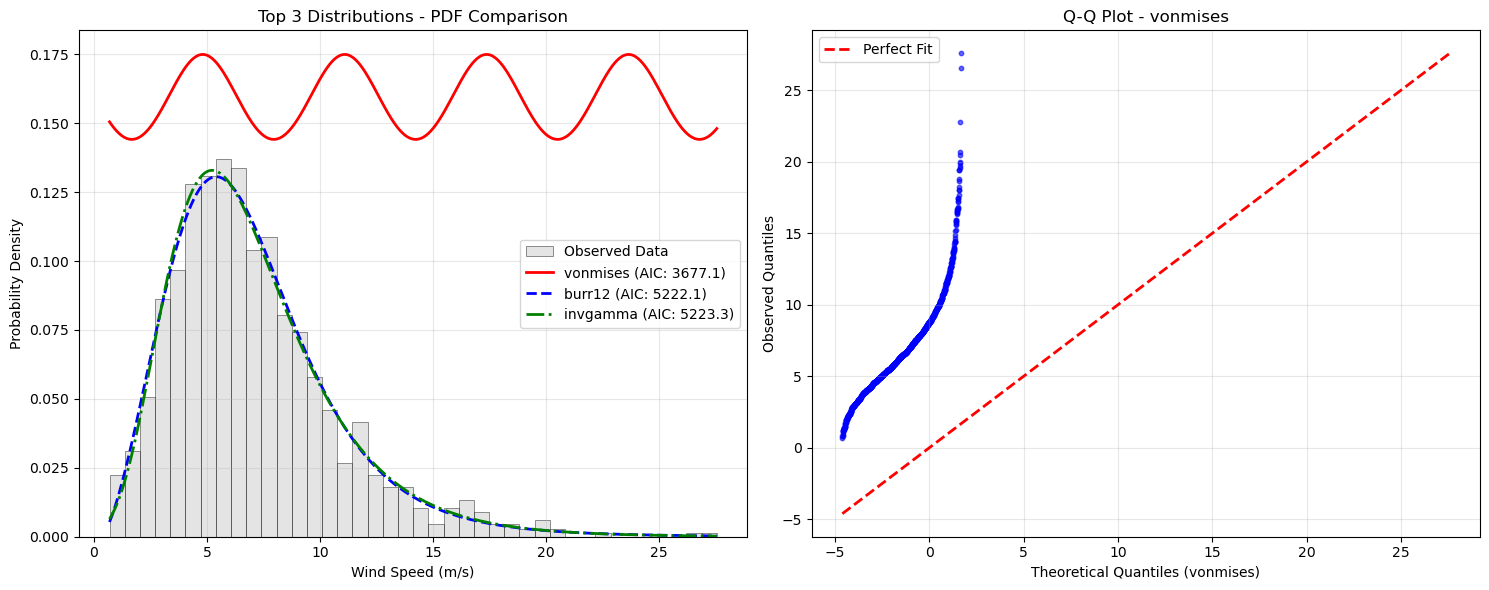


📊 Detailed Comparison of Top 3 Distributions:
Distribution         AIC      RMSE         KS p-val   Parameters
vonmises             3677.1   1.396219     0.0000     (3 params)
burr12               5222.1   0.005249     0.9877     (4 params)
invgamma             5223.3   0.005408     0.9879     (3 params)


In [11]:
# Get top 3 distributions from comprehensive analysis
top_3_dists = [dist for dist, _ in successful_comprehensive[:3]]
colors = ['red', 'blue', 'green']
linestyles = ['-', '--', '-.']

print(f"Visualizing top 3 distributions: {top_3_dists}")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Histogram with fitted PDFs
ax1.hist(wind_data, bins=40, density=True, alpha=0.6, color='lightgray', 
         label='Observed Data', edgecolor='black', linewidth=0.5)

# Generate smooth curves for top distributions
x_smooth = np.linspace(wind_data.min(), wind_data.max(), 500)

for i, dist_name in enumerate(top_3_dists):
    # Get the fitted adjuster for this distribution
    result = comprehensive_comparison[dist_name]
    
    # Create temporary processor and fit
    temp_processor = ma.read_data(wind_data)
    temp_processor.fit_distribution(dist_name)
    
    # Plot PDF
    pdf_smooth = temp_processor.pdf(x_smooth)
    ax1.plot(x_smooth, pdf_smooth, color=colors[i], linestyle=linestyles[i], 
            linewidth=2, label=f'{dist_name} (AIC: {result["aic"]:.1f})')

ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Top 3 Distributions - PDF Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for best distribution
best_dist_name = top_3_dists[0]
temp_processor = ma.read_data(wind_data)
temp_processor.fit_distribution(best_dist_name)

# Generate theoretical quantiles
sorted_data = np.sort(wind_data)
n = len(sorted_data)
theoretical_quantiles = temp_processor.ppf(np.arange(1, n+1) / (n+1))

ax2.scatter(theoretical_quantiles, sorted_data, alpha=0.6, s=10, color='blue')
# Add reference line
min_val = min(theoretical_quantiles.min(), sorted_data.min())
max_val = max(theoretical_quantiles.max(), sorted_data.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

ax2.set_xlabel(f'Theoretical Quantiles ({best_dist_name})')
ax2.set_ylabel('Observed Quantiles')
ax2.set_title(f'Q-Q Plot - {best_dist_name}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print goodness-of-fit metrics for top 3
print("\n📊 Detailed Comparison of Top 3 Distributions:")
print("=" * 70)
print(f"{'Distribution':<20} {'AIC':<8} {'RMSE':<12} {'KS p-val':<10} {'Parameters'}")
print("=" * 70)

for dist_name in top_3_dists:
    result = comprehensive_comparison[dist_name]
    params_str = f"({len(result['parameters'])} params)"
    print(f"{dist_name:<20} {result['aic']:<8.1f} {result['rmse']:<12.6f} {result['ks_pvalue']:<10.4f} {params_str}")

## Summary and Best Practices

### Key AutoFitter Features:

1. **Multiple Testing Strategies**:
   - **Default**: 16 curated, stable distributions (fast, reliable)
   - **Comprehensive**: All 113 SciPy distributions (thorough, slower)
   - **Custom**: Domain-specific distribution subsets

2. **Selection Criteria**:
   - `rmse`: Root Mean Square Error (good for overall fit)
   - `aic`/`bic`: Information criteria (balance fit vs complexity)
   - `ks_pvalue`/`chi2_pvalue`: Statistical test p-values

3. **Memory Efficiency**:
   - Lazy initialization - distributions fitted only when tested
   - Failed fits don't crash the process
   - Comprehensive error handling

### Recommended Workflow:

```python
# 1. Start with default (fast screening)
auto_fitter = processor.get_auto_fitter()
best_default = auto_fitter.fit_best_distribution()

# 2. If needed, do comprehensive search
all_dists = AutoFitter.get_all_available_distributions()
auto_fitter_all = processor.get_auto_fitter(candidates=all_dists)
best_comprehensive = auto_fitter_all.fit_best_distribution()

# 3. Use the best distribution
best_adjuster = auto_fitter.get_best_adjuster()
percentile_95 = best_adjuster.ppf(0.95)
```

### When to Use What:

- **Default AutoFitter**: Quick analysis, most real-world cases
- **Comprehensive AutoFitter**: Research, when you need the absolute best fit
- **Custom candidates**: Domain expertise, specific requirements
- **Different criteria**: AIC/BIC for model selection, p-values for statistical validity

**AutoFitter makes distribution selection effortless while giving you complete control when needed!** 🎯